In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
if '../' not in sys.path:
    sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d, UnivariateSpline
from scipy.integrate import quad

from mcp_boltzmann.gstar import *

/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:14: RuntimeWarning: overflow encountered in exp
  return u**2*np.sqrt(u**2-z**2)/(np.exp(u) + 1)
/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:17: RuntimeWarning: overflow encountered in exp
  return (u**2 - z**2)**(1.5)/(np.exp(u) + 1)


## Plot g* for energy and pressure densities, with and without neutrinos

In [24]:
gstar_E_EM(10.0000e+00)

array(5.51)

In [23]:
from mcp_boltzmann.gstar import _g_P_EM_I, _g_E_no_nu, _g_P_no_nu, _T_grid
_g_E_no_nu

array([101.5 , 101.5 , 101.49, 101.47, 101.36, 100.65,  98.28,  92.15,
        83.2 ,  80.97,  80.35,  77.25,  71.09,  64.01,  57.24,  57.24,
        45.5 ,  38.76,  33.02,  28.22,  24.26,  21.07,  18.52,  16.51,
        12.75,   9.38,   6.08,   5.51,   5.49,   5.46,   5.35,   5.22,
         4.04,   2.52,   2.01,   2.  ,   2.  ])

In [17]:
_T_grid

array([1.0000e+07, 5.0000e+06, 2.0000e+06, 1.0000e+06, 5.0000e+05,
       2.0000e+05, 1.0000e+05, 5.0000e+04, 2.0000e+04, 1.0000e+04,
       5.0000e+03, 2.0000e+03, 1.0000e+03, 5.0000e+02, 2.1401e+02,
       2.1399e+02, 2.0000e+02, 1.9000e+02, 1.8000e+02, 1.7000e+02,
       1.6000e+02, 1.5000e+02, 1.4000e+02, 1.3000e+02, 1.0000e+02,
       5.0000e+01, 2.0000e+01, 1.0000e+01, 5.0000e+00, 2.0000e+00,
       1.0000e+00, 5.0000e-01, 2.0000e-01, 1.0000e-01, 5.0000e-02,
       2.0000e-02, 1.0000e-02])

/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:14: RuntimeWarning: overflow encountered in exp
  return u**2*np.sqrt(u**2-z**2)/(np.exp(u) + 1)
/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:17: RuntimeWarning: overflow encountered in exp
  return (u**2 - z**2)**(1.5)/(np.exp(u) + 1)


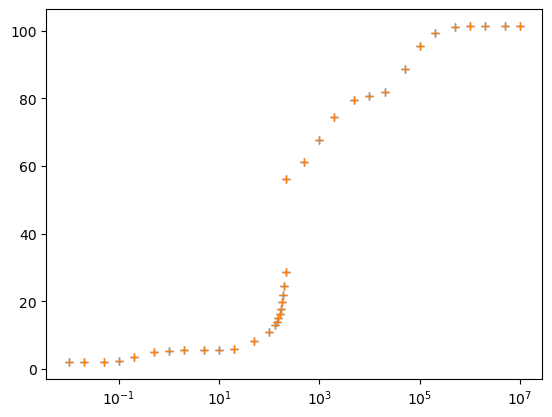

In [25]:
plt.plot(_T_grid, _g_P_no_nu, linestyle='none', marker='+')
plt.plot(_T_grid, gstar_P_EM(_T_grid), linestyle='none', marker='+')
# plt.plot(T, gstar_P_EM(T), linestyle='none',  marker='+')
plt.xscale('log')

In [ ]:
 5.000*1e3/0.05

In [ ]:
LQCD = 214
T = np.geomspace(1e-2, 2e7)
# plt.plot(T, g_E, color='C0', label=r'$g_{\epsilon}$')
# plt.plot(T, g_P, color='C0', linestyle='dashed', label=r'$g_{p}$')
plt.plot(T, gstar_E_EM(T), color='C1', label=r'$g_{\epsilon, \rm{no-}\nu}$')
# plt.plot(T, gstar_P_EM(T), color='C1', linestyle='dashed', label=r'$g_{p, \rm{no-}\nu}$')
plt.axvline(LQCD, color='purple', linestyle='dashed', linewidth=0.5)

plt.xlabel('Temperature [MeV]')
plt.ylabel('g(T)')

plt.xscale('log')
plt.gca().invert_xaxis()

plt.ylim(0, 110)

plt.legend()
plt.show()

## Derivatve of g* for Energy density

In [ ]:
plt.plot(T, d_gstar_E_EM_dT(T))
plt.axvline(LQCD, color='purple', linestyle='dashed', linewidth=0.5)

plt.gca().invert_xaxis()

plt.xscale('log')
plt.ylabel(r'$\frac{\partial g(T)}{\partial T}$ [MeV$^{-1}$')
plt.xlabel('Temperature [MeV]')
plt.show()

### EM Plasma Energy Density

In [ ]:
def rho_EM(T):
    return (np.pi**2/30)*gstar_E_EM(T)*T**4

def drho_EM_dT(T):
    return 4*(np.pi**2/30)*gstar_E_EM(T)*T**3 + (np.pi**2/30)*d_gstar_E_EM_dT(T)*T**4

In [ ]:
gstar_E_EM(0.00014)

In [ ]:
plt.plot(T, rho_EM(T))

plt.xlabel('Temperature [MeV]')
plt.ylabel(r'Energy Density [MeV$^4$]')

plt.yscale('log')
plt.xscale('log')

plt.gca().invert_xaxis()

plt.show()

In [ ]:
plt.plot(T, drho_EM_dT(T))

plt.xlabel('Temperature [MeV]')
plt.ylabel(r'Derivative of Energy Density [MeV$^3$]')

plt.yscale('log')
plt.xscale('log')

plt.gca().invert_xaxis()

plt.show()

## Calculate equation of state for electromagnetic plasma

In [ ]:
def EM_eos(T):
    return g_P_EM(T)/(3*g_E_EM(T))

In [ ]:
plt.plot(T, w_EM(T))

plt.xscale('log')
plt.gca().invert_xaxis()
plt.ylabel('w(T)')
plt.xlabel('Temperature [MeV]')

plt.axhline(1/3, linestyle='dashed', color='black', alpha=0.6)